機械学習を使ってフェイクニュースかどうかを判別する<br>
使用したデータセット
https://www.kaggle.com/datasets/emineyetm/fake-news-detection-datasets?resource=download <br>
各ツールをインストール -> pip install pandas scikit-learn matplot

In [2]:
#FakeとTrueのデータセットを結合して、FakeNewsdataset.csvという新しいファイルを作成するコード
import pandas as pd

fake = pd.read_csv('../Data/Fake.csv')
fake['label'] = 'fake' #fakeデータにラベルを追加

true = pd.read_csv('../Data/True.csv')
true['label'] = 'true' #trueデータにラベルを追加

df = pd.concat([fake, true], ignore_index=True) #fakeとtrueのデータを結合してDataFrameに変換
df.to_csv('../Data/FakeNewsdataset.csv', index=False) #csvファイルをDataディレクトリに保存

結合したデータセットを読み込んで、学習用データとテスト用データに分割

In [3]:
from sklearn.model_selection import train_test_split
import pandas as pd

df = pd.read_csv("../Data/FakeNewsdataset.csv", quotechar='"', sep=",") #結合したデータセットを読み込む

#欠損値があるかを確認
missing = df["text"].isna().sum()
print("Missing text:", missing)

#欠損があれば空文字で埋める
if missing > 0:
    df["text"] = df["text"].fillna("")

Missing text: 0


In [4]:
texts = df["text"] #テキスト列を抽出
label = df["label"] #ラベル列を抽出

x_train, x_test, y_train, y_test = train_test_split(texts, label, test_size=0.2, random_state=2) #データセットを訓練用とテスト用に分割

print(x_train.head()) #訓練用の先頭データを表示
print(y_train.head())

10185    MSNBC s Brian Williams spoke the truth on Tues...
17269    Don t worry the liberal elite always know what...
29275     (In this Jan. 31 story, in 11th paragraph cor...
12668    Every single day for months on end, new eviden...
39427    DUBLIN (Reuters) - The continuing failure of I...
Name: text, dtype: str
10185    fake
17269    fake
29275    true
12668    fake
39427    true
Name: label, dtype: str


テキストデータの前処理をそれぞれ実行<br>
nltkをコマンドでインストール -> pip install nltk<br>
nltk.download("stopwords")を一回実行

In [5]:
import re
from nltk.corpus import stopwords


def NormalizeText(text):
    text = text.lower() #テキストを小文字変換
    text = text.replace('\n', ' ') #改行をスペースに置換
    text = re.sub(r'[^\w\s]', '', text) #特殊文字を削除
    text = text.strip() #テキストの前後の空白を削除
    return text

def TokenizeText(text):
    tokens = re.findall(r'\b\w+\b',text) #テキストをスペースで分割してトークン化
    return tokens

def StopWordRemoval(tokens):
    stop_words = set(stopwords.words('english')) #英語のストップワードを取得
    filtered_tokens = [word for word in tokens if word not in stop_words] #ストップワードを除去
    return filtered_tokens

def Preprocessing(x_text): #前処理をまとめたもの
    x_text_Normalized = x_text.apply(NormalizeText) #訓練用テキストを正規化
    x_text_Tokenized = x_text_Normalized.apply(TokenizeText) #訓練用テキストをトークン化
    x_text_Filtered = x_text_Tokenized.apply(StopWordRemoval) #ストップワードを除去
    return x_text_Filtered

x_train_Filtered = Preprocessing(x_train) #前処理を実行
x_test_Filtered = Preprocessing(x_test)

x_train_Filtered.head() #処理された訓練用テキストの先頭データを表示


10185    [msnbc, brian, williams, spoke, truth, tuesday...
17269    [worry, liberal, elite, always, know, best, li...
29275    [jan, 31, story, 11th, paragraph, corrects, sh...
12668    [every, single, day, months, end, new, evidenc...
39427    [dublin, reuters, continuing, failure, irish, ...
Name: text, dtype: object

labelのデータをfake,trueから0,1に変換

In [6]:
def map_label(label):
    if label == 'fake':
        return 0
    else:
        return 1

def LabelTranslate(y_label):
    y_label_mapped = y_label.apply(map_label) #ラベルを数値に変換
    return y_label_mapped

y_train_mapped = LabelTranslate(y_train)
y_test_mapped = LabelTranslate(y_test)

y_train_mapped.head() #変換された訓練用ラベルの先頭データを表示

10185    0
17269    0
29275    1
12668    0
39427    1
Name: label, dtype: int64

前処理をしたx_train_Filteredを使って語彙についてのマッピングをする。

In [7]:
from collections import Counter

def VocabMapping(x_Filtered):
    vocab = Counter([word for tokens in x_Filtered for word in tokens]) #訓練用テキストの単語の出現頻度をカウント
    vocab = [word for word, count in vocab.items() if count >= 5]  #出現した中で５回以上出現したものだけにする
    word2idx = {word: i for i, word in enumerate(vocab)} 
    return vocab, word2idx

vocab, word2idx = VocabMapping(x_train_Filtered)

文章をベクトル化(Bag of Words)

In [8]:
import numpy as np

def bow_vector(tokens, vocab, word2idx): #一つの文章に対するベクトルを求める
    vec = np.zeros(len(vocab))
    for word in tokens:
        if word in word2idx:
            vec[word2idx[word]] += 1
    return vec

def BoW(x_Filtered, vocab, word2idx): #それぞれの文章のベクトルを集合としてx_vecに
    x_vec = np.array([bow_vector(tokens, vocab, word2idx) for tokens in x_Filtered])
    return x_vec

x_train_vec = BoW(x_train_Filtered, vocab, word2idx)
x_test_vec = BoW(x_test_Filtered, vocab, word2idx)

ロジスティック回帰で分類

In [9]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, accuracy_score

def Learning(x_vec, y_mapped):
    clf = LogisticRegression(max_iter=2000)
    clf.fit(x_vec, y_mapped)
    return clf

def DispResult(clf, x_test_vec, y_test_mapped):
    y_pred = clf.predict(x_test_vec)
    print(classification_report(y_test_mapped, y_pred))
    accuracy = accuracy_score(y_test_mapped, y_pred)
    return accuracy


clf = Learning(x_train_vec, y_train_mapped)
DispResult(clf, x_test_vec, y_test_mapped)

              precision    recall  f1-score   support

           0       1.00      1.00      1.00      4704
           1       1.00      1.00      1.00      4276

    accuracy                           1.00      8980
   macro avg       1.00      1.00      1.00      8980
weighted avg       1.00      1.00      1.00      8980



0.9969933184855234

以上の学習ではあまりにも精度が高すぎる。

In [10]:
set_train = set([" ".join(tokens) for tokens in x_train_Filtered])
set_test = set([" ".join(tokens) for tokens in x_test_Filtered])

len(set_train & set_test)


1745

学習データと検証用データの重複があったため、データ読み込みのときにデータの重複を消去する処理を加える

In [11]:
from sklearn.model_selection import train_test_split
import pandas as pd

df = pd.read_csv("../Data/FakeNewsdataset.csv", quotechar='"', sep=",") #結合したデータセットを読み込む
df_unique = df.drop_duplicates(subset=['text']) #追加 : 重複をなくしたデータにする
texts = df_unique["text"] #テキスト列を抽出
label = df_unique["label"] #ラベル列を抽出

x_train, x_test, y_train, y_test = train_test_split(texts, label, test_size=0.2, random_state=2) #データセットを訓練用とテスト用に分割

print(x_train.head()) #訓練用の先頭データを表示
print(y_train.head())

6896     Trump made a visit to the Keystone State in an...
43309    DUBAI (Reuters) - Iran will not be bullied by ...
29193    WASHINGTON (Reuters) - A veteran CIA clandesti...
26972    WASHINGTON (Reuters) - A political feud erupte...
14510    Tell us again Barack, about the  poor widows a...
Name: text, dtype: str
6896     fake
43309    true
29193    true
26972    true
14510    fake
Name: label, dtype: str


In [12]:
x_train_Filtered = Preprocessing(x_train) #前処理
x_test_Filtered = Preprocessing(x_test)

y_train_mapped = LabelTranslate(y_train) #Fake,Trueを0,1へ
y_test_mapped = LabelTranslate(y_test)

vocab, word2idx = VocabMapping(x_train_Filtered) #語彙のマッピング

x_train_vec = BoW(x_train_Filtered, vocab,  word2idx) #文章の集合をベクトルの集合へ
x_test_vec = BoW(x_test_Filtered, vocab,  word2idx)

clf = Learning(x_train_vec, y_train_mapped) #学習
DispResult(clf, x_test_vec, y_test_mapped) #結果表示

              precision    recall  f1-score   support

           0       1.00      0.99      0.99      3472
           1       0.99      1.00      1.00      4258

    accuracy                           0.99      7730
   macro avg       0.99      0.99      0.99      7730
weighted avg       0.99      0.99      0.99      7730



0.9948253557567918

以上の重複を除いてもまだ精度が高い

マッピングされた語彙の数を見る

In [13]:
len(vocab)

42284

５回以上出現する語彙だけで40000を超えているため、マッピングを制限する

In [14]:
from collections import Counter

def VocabMapping_Limit(x_Filtered, limit):
    vocab_counter = Counter([word for tokens in x_Filtered for word in tokens]) #訓練用テキストの単語の出現頻度をカウント
    vocab_top = vocab_counter.most_common(limit) #上位 limit 語を取得
    vocab = [word for word, count in vocab_top] #単語を取り出す
    word2idx = {word: i for i, word in enumerate(vocab)} 
    return vocab, word2idx

In [15]:
x_train_Filtered = Preprocessing(x_train) #前処理
x_test_Filtered = Preprocessing(x_test)

y_train_mapped = LabelTranslate(y_train) #Fake,Trueを0,1へ
y_test_mapped = LabelTranslate(y_test)

vocab, word2idx = VocabMapping_Limit(x_train_Filtered, 5000) #語彙のマッピング

x_train_vec = BoW(x_train_Filtered, vocab, word2idx) #文章の集合をベクトルの集合へ
x_test_vec = BoW(x_test_Filtered, vocab, word2idx)

clf = Learning(x_train_vec, y_train_mapped) #学習
DispResult(clf, x_test_vec, y_test_mapped) #結果表示

              precision    recall  f1-score   support

           0       0.99      0.99      0.99      3472
           1       0.99      1.00      0.99      4258

    accuracy                           0.99      7730
   macro avg       0.99      0.99      0.99      7730
weighted avg       0.99      0.99      0.99      7730



0.9943078913324709

結果は制限する前とほぼ変わらなかったが、全体の処理時間が1/2程度になったため制限をした方が良い。
どれほど制限すれば精度が下がるのかを検証した結果が以下

[0.7272962483829237, 0.7902975420439845, 0.8200517464424321, 0.8346701164294955, 0.9943078913324709, 0.994437257438551, 0.9943078913324709, 0.9936610608020698, 0.9936610608020698, 0.9914618369987064, 0.991849935316947, 0.9943078913324709]


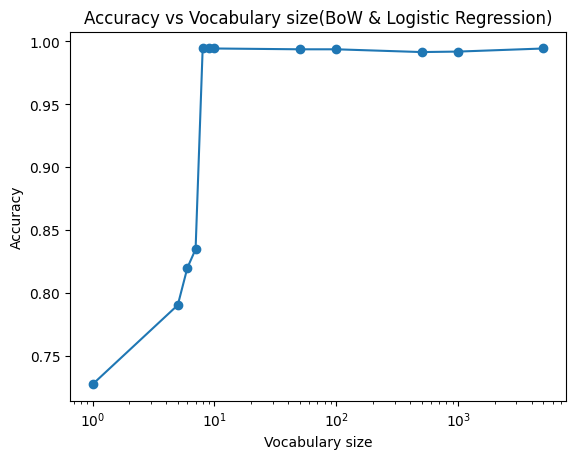

In [16]:
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score

def GetAccuracy(clf, x_test_vec, y_test_mapped):
    y_pred = clf.predict(x_test_vec)
    return accuracy_score(y_test_mapped, y_pred)
    
vocab_sizes = [1,5,6,7,8,9,10,50,100,500,1000,5000]
accuracies = [0] * 12

for i in range(12):
    vocab, word2idx = VocabMapping_Limit(x_train_Filtered, vocab_sizes[i])
    x_train_vec = BoW(x_train_Filtered, vocab, word2idx)
    x_test_vec = BoW(x_test_Filtered, vocab, word2idx)
    clf = Learning(x_train_vec, y_train_mapped)
    accuracies[i] = GetAccuracy(clf, x_test_vec, y_test_mapped)

print(accuracies)

plt.plot(vocab_sizes, accuracies, marker="o")
plt.xlabel("Vocabulary size")
plt.ylabel("Accuracy")
plt.title("Accuracy vs Vocabulary size(BoW & Logistic Regression)")
plt.xscale("log")
plt.show

plt.savefig("../Figures/BoW&LogisticRegression_accuracy_vs_vocab_size.png",dpi=300, bbox_inches="tight")

上の結果から8語目で急激に精度が向上している。それ以上語彙を追加しても精度は向上しない。

語彙数と処理時間の関係は次のグラフの通り。処理時間は語彙のマッピング、文章のベクトル集合への変換と学習時間の総和とした。

[2.0726318359375, 2.1826071739196777, 2.2412219047546387, 2.4361345767974854, 2.609356641769409, 3.6707587242126465, 4.547079801559448, 10.826422929763794]


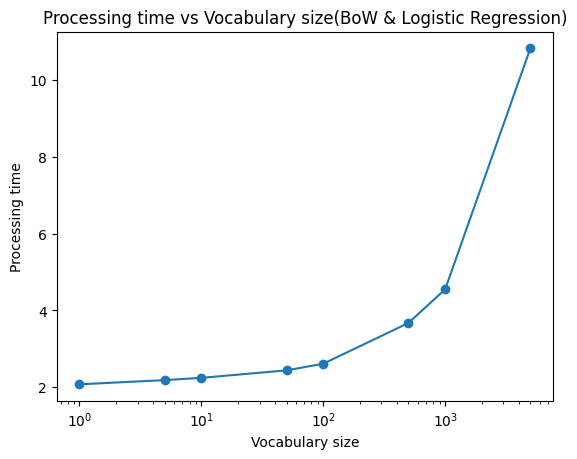

In [17]:
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score
import time

def measure_time(x_train_Filtered, x_test_Filtered, y_train_mapped, limit):
    start = time.time()
    vocab, word2idx = VocabMapping_Limit(x_train_Filtered, limit)
    x_train_vec = BoW(x_train_Filtered, vocab, word2idx)
    x_test_vec = BoW(x_test_Filtered, vocab, word2idx)
    clf = Learning(x_train_vec, y_train_mapped)
    end = time.time()
    return end - start
    
vocab_sizes = [1,5,10,50,100,500,1000,5000]
processing_time = [0] * 8

for i in range(8):
    processing_time[i] = measure_time(x_train_Filtered, x_test_Filtered, y_train_mapped, vocab_sizes[i])

print(processing_time)

plt.plot(vocab_sizes, processing_time, marker="o")
plt.xlabel("Vocabulary size")
plt.ylabel("Processing time")
plt.title("Processing time vs Vocabulary size(BoW & Logistic Regression)")
plt.xscale("log")
plt.show

plt.savefig("../Figures/BoW&LogisticRegression_ProcessingTime_vs_vocab_size.png", dpi=300, bbox_inches="tight")

以上の結果から、今回のデータセットではFakeとTrueを判別するのに必要な語彙が少なかったことから英文のフェイクニュースにはかなりの特徴量があることが分かった。そして、9語以上の語彙をモデルに持たせても結果に変化はなく処理時間が増加するだけのことから、このデータセットでは多くとも10語程度でモデルを作成した方がコストがかからない。